# Sentiment Analyser

This notebook builds an end‑to‑end workflow for sentiment analysis of financial news headlines/articles.  
It includes: cleaning, exploratory analysis, feature engineering, class balancing strategies, multiple linear models, tuning, evaluation, and error analysis.  

The source for the dataset used is from the study : [https://www.researchgate.net/publication/251231107_Good_Debt_or_Bad_Debt_Detecting_Semantic_Orientations_in_Economic_Texts](https://www.researchgate.net/publication/251231107_Good_Debt_or_Bad_Debt_Detecting_Semantic_Orientations_in_Economic_Texts)

The data is cleaned already (by me) and converted to label, text columns. The data is stored in the data folder. 

**Sections**
1. Setup
2. Load Data
3. Quick Data Audit
4. Text Cleaning
5. Exploratory Data Analysis
6. Word Clouds
7. Train/Validation Split
8. Feature Extraction (Bag of Words & TF‑IDF, word & char n‑grams)
9. Baselines & Linear Models
10. Class Balancing Approaches
11. Hyperparameter Tuning
12. Evaluation & Error Analysis
13. Feature Interpretability
14. Save Model
15. Try new news headlines


### Setup

In [20]:
import os
import re
import sys
import math
import json
import time
import string
import pickle
import random
import numpy as np
import pandas as pd
from collections import Counter, defaultdict

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


3.6.3 (v3.6.3:2c5fed8, Oct  3 2017, 18:11:49) [MSC v.1900 64 bit (AMD64)]
NumPy: 1.17.5
Pandas: 0.24.2


### Load Data

In [25]:
DATA_PATH = "data/financial_news.csv"

df = pd.read_csv(DATA_PATH, encoding="latin-1", header=None, names=["label", "text"])

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (4846, 2)
Columns: ['label', 'text']


,label,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


### Data checks

In [26]:

# Basic NA checks
print(df.isna().sum())

# Drop fully empty text rows
df = df.dropna(subset=[TEXT_COL]).copy()

# Standardize label to string category (strip whitespace)
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

# Basic label overview
print("Unique labels:", df[LABEL_COL].unique())
label_counts = df[LABEL_COL].value_counts(dropna=False)
display(label_counts)

# Basic text length statistics
df["text_len"] = df[TEXT_COL].astype(str).str.len()
df["word_count"] = df[TEXT_COL].astype(str).str.split().apply(len)
df[["text_len","word_count"]].describe()


label    0
text     0
dtype: int64
Unique labels: ['neutral' 'negative' 'positive']


neutral     2879
positive    1363
negative     604
Name: label, dtype: int64

,text_len,word_count
count,4846.000000,4846.000000
mean,128.132068,23.101114
std,56.526180,9.958474
min,9.000000,2.000000
25%,84.000000,16.000000
50%,119.000000,21.000000
75%,163.000000,29.000000
max,315.000000,81.000000


Some class imbalance - will address it later

### Cleaning

In [27]:

import nltk

# Download once; harmless if already present
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(s):
    if not isinstance(s, str):
        s = str(s)
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", " ", s)        # URLs
    s = re.sub(r"\d+", " ", s)                    # numbers
    s = re.sub(r"[^a-z\s]", " ", s)               # keep letters & space
    s = re.sub(r"\s+", " ", s).strip()
    tokens = [w for w in s.split() if w not in STOPWORDS]
    lemmas = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(lemmas)

df["clean_text"] = df[TEXT_COL].astype(str).apply(clean_text)

df[["clean_text"]].head()


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\VictorJohnson\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_text
0,according gran company plan move production ru...
1,technopolis plan develop stage area le square ...
2,international electronic industry company elco...
3,new production plant company would increase ca...
4,according company updated strategy year baswar...


### EDA

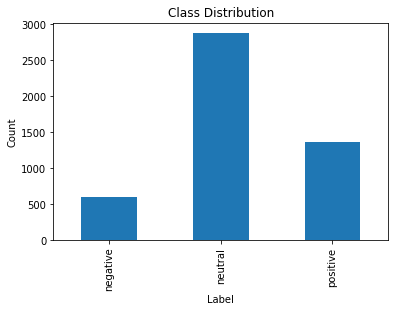

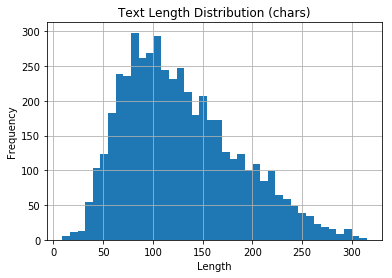

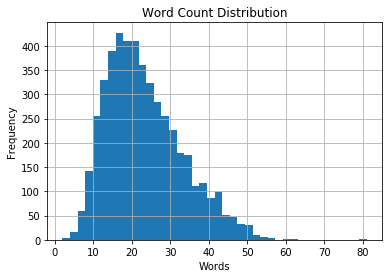


Top tokens for label: negative
eur                  417
mn                   237
profit               159
company              108
year                 104
net                  104
sale                 102
finnish              102
operating            97
period               91
quarter              90
million              78
said                 77
loss                 74
compared             68
decreased            68
mln                  68
first                59
oyj                  51
share                50

Top tokens for label: neutral
company              592
eur                  359
share                305
said                 238
finland              228
service              227
finnish              220
business             212
sale                 197
group                194
million              193
new                  189
market               185
also                 145
product              124
year                 113
net                  113
total                107

In [28]:

# Class distribution
counts = df[LABEL_COL].value_counts().sort_index()
plt.figure(figsize=(6,4))
counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Text length distribution (characters)
plt.figure(figsize=(6,4))
df["text_len"].hist(bins=40)
plt.title("Text Length Distribution (chars)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# Word count distribution
plt.figure(figsize=(6,4))
df["word_count"].hist(bins=40)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

# Top tokens per class (simple counts)
def top_tokens_for_label(label, k=20):
    subset = df[df[LABEL_COL] == label]["clean_text"].dropna()
    tokens = " ".join(list(subset)).split()
    cnt = Counter(tokens)
    return cnt.most_common(k)

for lab in counts.index:
    print("\nTop tokens for label:", lab)
    for w, c in top_tokens_for_label(lab, 20):
        print(f"{w:20s} {c}")


### Word Cloud

Lets see what the word cloud gives

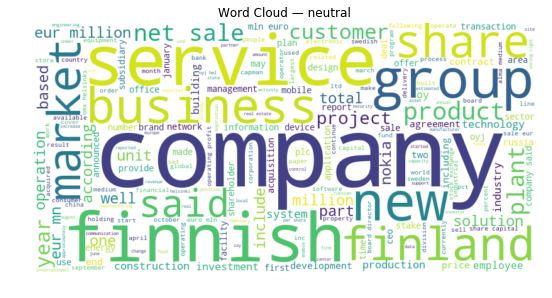

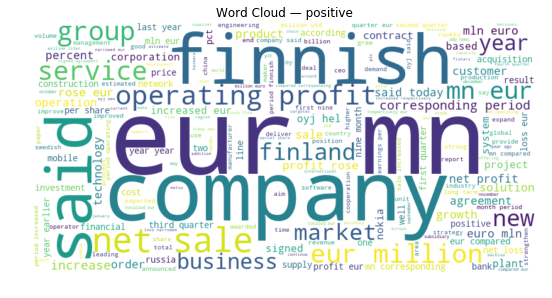

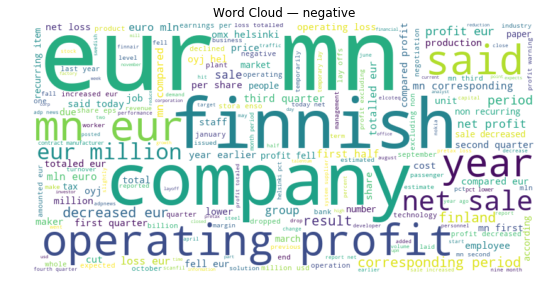

In [29]:

try:
    from wordcloud import WordCloud
    def plot_wc(texts, title):
        text = " ".join(texts.astype(str).tolist())
        wc = WordCloud(width=800, height=400, background_color="white").generate(text)
        plt.figure(figsize=(9,5))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()

    for lab in df[LABEL_COL].value_counts().index:
        plot_wc(df[df[LABEL_COL]==lab]["clean_text"], f"Word Cloud — {lab}")
except Exception as e:
    print("WordCloud not available. Install it and re-run this cell if you'd like visualizations.")
    print("Error:", e)


### Training set and validation test splitting

In [30]:

from sklearn.model_selection import train_test_split

X = df["clean_text"].astype(str).values
y = df[LABEL_COL].values

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train size:", len(X_train), "Valid size:", len(X_valid))


Train size: 3876 Valid size: 970


### Feature Extraction

In [31]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Word-level TF-IDF
tfidf_word = TfidfVectorizer(
    ngram_range=(1,2),              # unigrams + bigrams
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

# Char-level TF-IDF (helps with misspellings, short texts)
tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=2,
    sublinear_tf=True
)

# Fit on training only; transform train/valid
Xtr_word = tfidf_word.fit_transform(X_train)
Xva_word = tfidf_word.transform(X_valid)

Xtr_char = tfidf_char.fit_transform(X_train)
Xva_char = tfidf_char.transform(X_valid)

Xtr_word.shape, Xtr_char.shape


((3876, 7493), (3876, 46614))

### Model Training

Trying some baseline and linear models

In [32]:

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

def eval_and_print(model, Xtr, ytr, Xva, yva, title):
    model.fit(Xtr, ytr)
    pred = model.predict(Xva)
    print("\n===", title, "===")
    print("Accuracy:", accuracy_score(yva, pred))
    print("F1 (macro):", f1_score(yva, pred, average="macro"))
    print("\nClassification Report:\n", classification_report(yva, pred))
    print("Confusion Matrix:\n", confusion_matrix(yva, pred))
    return model, pred

results = {}

# Baseline: most frequent
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
_ , pred = eval_and_print(baseline, Xtr_word, y_train, Xva_word, y_valid, "Baseline (Most Frequent)")
results["baseline_mf"] = ("Dummy", pred)

# Multinomial NB on word features
nb_word = MultinomialNB(alpha=0.5)
nb_word, pred = eval_and_print(nb_word, Xtr_word, y_train, Xva_word, y_valid, "Multinomial NB (word TFIDF)")
results["nb_word"] = ("MNB", pred)

# Multinomial NB on char features
nb_char = MultinomialNB(alpha=0.5)
nb_char, pred = eval_and_print(nb_char, Xtr_char, y_train, Xva_char, y_valid, "Multinomial NB (char TFIDF)")
results["nb_char"] = ("MNB_char", pred)

# Logistic Regression (liblinear for small/medium datasets)
log_word = LogisticRegression(C=2.0, class_weight=None, solver="liblinear", multi_class="ovr", max_iter=1000, random_state=RANDOM_STATE)
log_word, pred = eval_and_print(log_word, Xtr_word, y_train, Xva_word, y_valid, "Logistic Regression (word TFIDF)")
results["log_word"] = ("LR_word", pred)

# Linear SVM
svc_word = LinearSVC(C=1.0, class_weight=None, random_state=RANDOM_STATE)
svc_word, pred = eval_and_print(svc_word, Xtr_word, y_train, Xva_word, y_valid, "Linear SVM (word TFIDF)")
results["svc_word"] = ("LinearSVC_word", pred)



=== Baseline (Most Frequent) ===
Accuracy: 0.5938144329896907
F1 (macro): 0.2483829236739974

Classification Report:
               precision    recall  f1-score   support

    negative       0.00      0.00      0.00       121
     neutral       0.59      1.00      0.75       576
    positive       0.00      0.00      0.00       273

   micro avg       0.59      0.59      0.59       970
   macro avg       0.20      0.33      0.25       970
weighted avg       0.35      0.59      0.44       970

Confusion Matrix:
 [[  0 121   0]
 [  0 576   0]
 [  0 273   0]]

=== Multinomial NB (word TFIDF) ===
Accuracy: 0.7195876288659794
F1 (macro): 0.6077646128346194

Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.34      0.48       121
     neutral       0.73      0.93      0.82       576
    positive       0.65      0.44      0.53       273

   micro avg       0.72      0.72      0.72       970
   macro avg       0.73      0.57      0.

c:\Users\VictorJohnson\Downloads\VJP\sentiment-analyser-financial-news\.venv\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)
c:\Users\VictorJohnson\Downloads\VJP\sentiment-analyser-financial-news\.venv\lib\site-packages\sklearn\metrics\classification.py:1143: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)



=== Multinomial NB (char TFIDF) ===
Accuracy: 0.6876288659793814
F1 (macro): 0.4973209205192733

Classification Report:
               precision    recall  f1-score   support

    negative       0.80      0.13      0.23       121
     neutral       0.70      0.96      0.81       576
    positive       0.61      0.36      0.46       273

   micro avg       0.69      0.69      0.69       970
   macro avg       0.70      0.48      0.50       970
weighted avg       0.69      0.69      0.64       970

Confusion Matrix:
 [[ 16  65  40]
 [  2 552  22]
 [  2 172  99]]

=== Logistic Regression (word TFIDF) ===
Accuracy: 0.7402061855670103
F1 (macro): 0.648559507219638

Classification Report:
               precision    recall  f1-score   support

    negative       0.78      0.41      0.54       121
     neutral       0.74      0.93      0.83       576
    positive       0.72      0.49      0.58       273

   micro avg       0.74      0.74      0.74       970
   macro avg       0.75      0.61 